# Group06 — NinaPro DB2 — Task 3 Explainability

## 1. Setup and Final Checkpoint

In [1]:
from pathlib import Path
import re
import random
import gc
import warnings
import math
import sys
import subprocess
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DATA_ROOT = Path(
    "/kaggle/input/datasets/quddusikashaf/ninapro-db2"
)

SUBJECTS = list(range(1, 41))
TRAIN_REPETITIONS = [1, 3, 4, 6]
TEST_REPETITIONS = [2, 5]

SAMPLING_RATE = 2000
N_CHANNELS = 12
N_CLASSES = 17
WINDOW_SIZE = 400
STEP_SIZE = 200
SIGNAL_THRESHOLD = 1e-6
WAMP_THRESHOLD = 1e-5
EPSILON = 1e-12
BATCH_SIZE = 384

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

ARCHIVE_DIR = Path(
    "/kaggle/input/models/mahfuzahmed17/"
    "ninapro-db2-pth-file/pytorch/default/1/"
    "Group06_NinaProDB2_best"
)

MODEL_PATH = Path(
    "/kaggle/working/Group06_NinaProDB2_best.pth"
)

EXPECTED_VARIANT = "Binary Edges"
EXPECTED_BEST_EPOCH = 36

assert DATA_ROOT.exists(), (
    f"Dataset not found: {DATA_ROOT}"
)

assert ARCHIVE_DIR.exists(), (
    f"Checkpoint folder not found: {ARCHIVE_DIR}"
)

assert (
    ARCHIVE_DIR / "data.pkl"
).exists(), (
    f"data.pkl not found inside: {ARCHIVE_DIR}"
)

with zipfile.ZipFile(
    MODEL_PATH,
    mode="w",
    compression=zipfile.ZIP_STORED,
) as zip_file:

    for file_path in sorted(
        ARCHIVE_DIR.rglob("*")
    ):
        if file_path.is_file():

            relative_path = file_path.relative_to(
                ARCHIVE_DIR
            )

            archive_name = (
                Path(ARCHIVE_DIR.name)
                / relative_path
            )

            zip_file.write(
                file_path,
                arcname=str(
                    archive_name
                ),
            )

assert MODEL_PATH.exists(), (
    "Checkpoint reconstruction failed."
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu",
    weights_only=False,
)

required_keys = [
    "model_state_dict",
    "model_config",
    "selected_variant",
    "best_epoch",
    "train_repetitions",
    "test_repetitions",
]

missing_keys = [
    key
    for key in required_keys
    if key not in checkpoint
]

assert not missing_keys, (
    f"Missing checkpoint keys: {missing_keys}"
)

assert checkpoint[
    "selected_variant"
] == EXPECTED_VARIANT, (
    "Wrong checkpoint variant: "
    f"{checkpoint['selected_variant']}"
)

assert int(
    checkpoint[
        "best_epoch"
    ]
) == EXPECTED_BEST_EPOCH, (
    "Wrong checkpoint epoch: "
    f"{checkpoint['best_epoch']}"
)

assert checkpoint[
    "train_repetitions"
] == TRAIN_REPETITIONS, (
    "Train repetition mismatch."
)

assert checkpoint[
    "test_repetitions"
] == TEST_REPETITIONS, (
    "Test repetition mismatch."
)

print(
    "Dataset root :",
    DATA_ROOT,
)

print(
    "Source folder:",
    ARCHIVE_DIR,
)

print(
    "Rebuilt model:",
    MODEL_PATH,
)

print(
    "Device       :",
    DEVICE,
)

print(
    "Model        :",
    checkpoint[
        "selected_variant"
    ],
)

print(
    "Best epoch   :",
    checkpoint[
        "best_epoch"
    ],
)

print(
    "Train reps   :",
    checkpoint[
        "train_repetitions"
    ],
)

print(
    "Test reps    :",
    checkpoint[
        "test_repetitions"
    ],
)

print(
    "\nCheckpoint check: PASSED"
)

Dataset root : /kaggle/input/datasets/quddusikashaf/ninapro-db2
Source folder: /kaggle/input/models/mahfuzahmed17/ninapro-db2-pth-file/pytorch/default/1/Group06_NinaProDB2_best
Rebuilt model: /kaggle/working/Group06_NinaProDB2_best.pth
Device       : cuda:0
Model        : Binary Edges
Best epoch   : 36
Train reps   : [1, 3, 4, 6]
Test reps    : [2, 5]

Checkpoint check: PASSED


## 2. Exercise B File Discovery

In [2]:
FILE_PATTERN = re.compile(
    r"S(\d+)_E1_A1\.mat$",
    re.IGNORECASE,
)

subject_files = {}

for path in sorted(DATA_ROOT.rglob("S*_E1_A1.mat")):
    match = FILE_PATTERN.search(path.name)

    if match:
        subject_id = int(match.group(1))

        if 1 <= subject_id <= 40:
            subject_files[subject_id] = path

assert len(subject_files) == 40

print("Exercise B files found:", len(subject_files))
print("File discovery: PASSED")


Exercise B files found: 40
File discovery: PASSED


## 3. Same Windowing and Features as the Final Model

In [3]:
BASE_FEATURE_NAMES = [
    "MAV",
    "RMS",
    "VAR",
    "WL",
    "ZC",
    "SSC",
    "WAMP",
    "DASDV",
    "IEMG",
    "LOGDET",
    "MNF",
    "MDF",
    "SPEC_ENT",
    "BAND_POWER",
    "PEAK_FREQ",
]

N_NODE_FEATURES = len(BASE_FEATURE_NAMES)

CHANNEL_FEATURE_COLUMNS = [
    f"ch{channel:02d}_{feature}"
    for channel in range(1, N_CHANNELS + 1)
    for feature in BASE_FEATURE_NAMES
]

CORR_PAIRS = [
    (i, j)
    for i in range(N_CHANNELS)
    for j in range(i + 1, N_CHANNELS)
]

CORR_FEATURE_COLUMNS = [
    f"corr_ch{i + 1:02d}_ch{j + 1:02d}"
    for i, j in CORR_PAIRS
]

ALL_FEATURE_COLUMNS = (
    CHANNEL_FEATURE_COLUMNS
    + CORR_FEATURE_COLUMNS
)

FREQUENCIES = np.fft.rfftfreq(
    WINDOW_SIZE,
    d=1.0 / SAMPLING_RATE,
)

FREQUENCY_MASK = (
    (FREQUENCIES >= 20.0)
    & (FREQUENCIES <= 450.0)
)

BAND_FREQUENCIES = FREQUENCIES[
    FREQUENCY_MASK
].astype(np.float64)


def load_e1_file(path):
    data = loadmat(
        path,
        variable_names=[
            "emg",
            "restimulus",
            "stimulus",
            "rerepetition",
            "repetition",
        ],
    )

    if "emg" not in data:
        raise KeyError(
            f"`emg` not found in {path.name}"
        )

    label_key = (
        "restimulus"
        if "restimulus" in data
        else "stimulus"
    )

    repetition_key = (
        "rerepetition"
        if "rerepetition" in data
        else "repetition"
    )

    if label_key not in data:
        raise KeyError(
            f"Gesture labels not found in {path.name}"
        )

    if repetition_key not in data:
        raise KeyError(
            f"Repetition labels not found in {path.name}"
        )

    emg = np.asarray(
        data["emg"],
        dtype=np.float32,
    )

    labels = np.asarray(
        data[label_key]
    ).squeeze()

    repetitions = np.asarray(
        data[repetition_key]
    ).squeeze()

    if (
        emg.ndim == 2
        and emg.shape[0] == N_CHANNELS
        and emg.shape[1] != N_CHANNELS
    ):
        emg = emg.T

    if (
        emg.ndim != 2
        or emg.shape[1] != N_CHANNELS
    ):
        raise ValueError(
            f"{path.name}: unexpected EMG shape {emg.shape}"
        )

    n_rows = min(
        len(emg),
        len(labels),
        len(repetitions),
    )

    emg = emg[:n_rows]
    labels = labels[:n_rows].astype(
        np.int16,
        copy=False,
    )
    repetitions = repetitions[:n_rows].astype(
        np.int16,
        copy=False,
    )

    return emg, labels, repetitions


def continuous_segments(
    labels,
    repetitions,
):
    if len(labels) == 0:
        return []

    change_points = np.where(
        (labels[1:] != labels[:-1])
        | (
            repetitions[1:]
            != repetitions[:-1]
        )
    )[0] + 1

    boundaries = np.concatenate(
        ([0], change_points, [len(labels)])
    )

    return [
        (
            int(boundaries[i]),
            int(boundaries[i + 1]),
        )
        for i in range(
            len(boundaries) - 1
        )
    ]


def extract_feature_matrix(windows):
    x = windows.astype(
        np.float64,
        copy=False,
    )

    absolute_x = np.abs(x)

    mav = np.mean(
        absolute_x,
        axis=1,
    )

    rms = np.sqrt(
        np.mean(
            np.square(x),
            axis=1,
        )
    )

    variance = np.var(
        x,
        axis=1,
    )

    differences = np.diff(
        x,
        axis=1,
    )

    waveform_length = np.sum(
        np.abs(differences),
        axis=1,
    )

    left = x[:, :-1, :]
    right = x[:, 1:, :]

    zero_crossing = np.sum(
        ((left * right) < 0)
        & (
            np.abs(left - right)
            >= SIGNAL_THRESHOLD
        ),
        axis=1,
    )

    first_difference = (
        x[:, 1:-1, :]
        - x[:, :-2, :]
    )

    second_difference = (
        x[:, 1:-1, :]
        - x[:, 2:, :]
    )

    slope_sign_change = np.sum(
        (
            (
                first_difference
                * second_difference
            ) > 0
        )
        & (
            (
                np.abs(first_difference)
                >= SIGNAL_THRESHOLD
            )
            | (
                np.abs(second_difference)
                >= SIGNAL_THRESHOLD
            )
        ),
        axis=1,
    )

    willison_amplitude = np.sum(
        np.abs(differences)
        >= WAMP_THRESHOLD,
        axis=1,
    )

    dasdv = np.sqrt(
        np.mean(
            np.square(differences),
            axis=1,
        )
    )

    integrated_emg = np.sum(
        absolute_x,
        axis=1,
    )

    log_detector = np.exp(
        np.mean(
            np.log(
                absolute_x
                + EPSILON
            ),
            axis=1,
        )
    )

    spectrum = np.fft.rfft(
        x,
        axis=1,
    )

    power = np.square(
        np.abs(spectrum)
    )

    band_power = power[
        :,
        FREQUENCY_MASK,
        :,
    ]

    total_band_power = np.sum(
        band_power,
        axis=1,
    ) + EPSILON

    mean_frequency = np.sum(
        band_power
        * BAND_FREQUENCIES[
            None,
            :,
            None,
        ],
        axis=1,
    ) / total_band_power

    cumulative_power = np.cumsum(
        band_power,
        axis=1,
    )

    median_index = np.argmax(
        cumulative_power
        >= (
            0.5
            * total_band_power[
                :,
                None,
                :,
            ]
        ),
        axis=1,
    )

    median_frequency = (
        BAND_FREQUENCIES[
            median_index
        ]
    )

    normalized_power = (
        band_power
        / total_band_power[
            :,
            None,
            :,
        ]
    )

    spectral_entropy = -np.sum(
        normalized_power
        * np.log(
            normalized_power
            + EPSILON
        ),
        axis=1,
    ) / np.log(
        band_power.shape[1]
    )

    peak_index = np.argmax(
        band_power,
        axis=1,
    )

    peak_frequency = (
        BAND_FREQUENCIES[
            peak_index
        ]
    )

    per_channel = np.stack(
        [
            mav,
            rms,
            variance,
            waveform_length,
            zero_crossing,
            slope_sign_change,
            willison_amplitude,
            dasdv,
            integrated_emg,
            log_detector,
            mean_frequency,
            median_frequency,
            spectral_entropy,
            total_band_power,
            peak_frequency,
        ],
        axis=2,
    )

    per_channel = per_channel.reshape(
        len(x),
        -1,
    )

    centered = (
        x
        - np.mean(
            x,
            axis=1,
            keepdims=True,
        )
    )

    covariance = np.einsum(
        "btc,btd->bcd",
        centered,
        centered,
    )

    energy = np.sqrt(
        np.sum(
            np.square(centered),
            axis=1,
        )
        + EPSILON
    )

    denominator = (
        energy[:, :, None]
        * energy[:, None, :]
    )

    correlation = (
        covariance
        / denominator
    )

    upper_i = np.array(
        [pair[0] for pair in CORR_PAIRS]
    )

    upper_j = np.array(
        [pair[1] for pair in CORR_PAIRS]
    )

    correlation_features = correlation[
        :,
        upper_i,
        upper_j,
    ]

    features = np.concatenate(
        [
            per_channel,
            correlation_features,
        ],
        axis=1,
    )

    features = np.nan_to_num(
        features,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(
        np.float32
    )

    return features


def process_subject_file(
    subject_id,
    path,
):
    emg, labels, repetitions = load_e1_file(
        path
    )

    feature_blocks = []
    raw_window_blocks = []
    metadata_blocks = []

    for start, end in continuous_segments(
        labels,
        repetitions,
    ):
        gesture = int(
            labels[start]
        )

        repetition = int(
            repetitions[start]
        )

        if gesture == 0:
            continue

        if not 1 <= gesture <= N_CLASSES:
            continue

        if repetition not in range(1, 7):
            continue

        if end - start < WINDOW_SIZE:
            continue

        window_starts = np.arange(
            start,
            end - WINDOW_SIZE + 1,
            STEP_SIZE,
            dtype=np.int64,
        )

        if len(window_starts) == 0:
            continue

        windows = np.stack(
            [
                emg[
                    window_start:
                    window_start
                    + WINDOW_SIZE
                ]
                for window_start
                in window_starts
            ],
            axis=0,
        ).astype(
            np.float32,
            copy=False,
        )

        features = extract_feature_matrix(
            windows
        )

        feature_blocks.append(
            features
        )

        raw_window_blocks.append(
            windows
        )

        metadata_blocks.append(
            np.column_stack(
                [
                    np.full(
                        len(features),
                        subject_id,
                    ),
                    np.full(
                        len(features),
                        gesture,
                    ),
                    np.full(
                        len(features),
                        repetition,
                    ),
                ]
            )
        )

    if not feature_blocks:
        raise ValueError(
            f"No valid windows extracted from {path.name}"
        )

    feature_matrix = np.vstack(
        feature_blocks
    )

    raw_windows = np.concatenate(
        raw_window_blocks,
        axis=0,
    ).astype(
        np.float32,
        copy=False,
    )

    metadata = np.vstack(
        metadata_blocks
    ).astype(
        np.int16
    )

    result = pd.DataFrame(
        feature_matrix,
        columns=ALL_FEATURE_COLUMNS,
    )

    result.insert(
        0,
        "repetition_id",
        metadata[:, 2],
    )

    result.insert(
        0,
        "gesture_label",
        metadata[:, 1],
    )

    result.insert(
        0,
        "subject_id",
        metadata[:, 0],
    )

    assert len(result) == len(raw_windows)

    return (
        result,
        raw_windows,
    )


print("Node features/electrode :", N_NODE_FEATURES)
print("Electrode features total:", len(CHANNEL_FEATURE_COLUMNS))
print("Correlation features    :", len(CORR_FEATURE_COLUMNS))
print("All baseline features   :", len(ALL_FEATURE_COLUMNS))
print("Raw samples/window      :", WINDOW_SIZE)

assert N_NODE_FEATURES == 15
assert len(CHANNEL_FEATURE_COLUMNS) == 180
assert len(CORR_FEATURE_COLUMNS) == 66
assert len(ALL_FEATURE_COLUMNS) == 246

print("\nFeature/raw-window extraction functions: READY")


Node features/electrode : 15
Electrode features total: 180
Correlation features    : 66
All baseline features   : 246
Raw samples/window      : 400

Feature/raw-window extraction functions: READY


## 4. Reconstruct the Final Repetition Split

In [4]:
subject_tables = []
subject_raw_windows = []

for subject_id in SUBJECTS:
    subject_df, subject_raw = process_subject_file(
        subject_id,
        subject_files[subject_id],
    )

    subject_tables.append(
        subject_df
    )

    subject_raw_windows.append(
        subject_raw
    )

    print(
        f"S{subject_id:02d} completed | "
        f"{len(subject_df):,} windows"
    )

    gc.collect()

all_df = pd.concat(
    subject_tables,
    ignore_index=True,
)

all_raw_windows = np.concatenate(
    subject_raw_windows,
    axis=0,
).astype(
    np.float32,
    copy=False,
)

del subject_tables
del subject_raw_windows
gc.collect()

assert len(all_df) == len(all_raw_windows)

print("\nAll windows:", f"{len(all_df):,}")
print("Subjects   :", all_df["subject_id"].nunique())
print("Gestures   :", all_df["gesture_label"].nunique())


S01 completed | 3,567 windows
S02 completed | 4,346 windows
S03 completed | 4,137 windows
S04 completed | 5,578 windows
S05 completed | 3,479 windows
S06 completed | 4,688 windows
S07 completed | 5,906 windows
S08 completed | 3,644 windows
S09 completed | 3,551 windows
S10 completed | 3,932 windows
S11 completed | 6,482 windows
S12 completed | 4,697 windows
S13 completed | 3,573 windows
S14 completed | 4,698 windows
S15 completed | 4,021 windows
S16 completed | 3,684 windows
S17 completed | 5,518 windows
S18 completed | 4,907 windows
S19 completed | 5,157 windows
S20 completed | 4,191 windows
S21 completed | 3,911 windows
S22 completed | 3,822 windows
S23 completed | 4,861 windows
S24 completed | 4,514 windows
S25 completed | 3,672 windows
S26 completed | 5,707 windows
S27 completed | 3,899 windows
S28 completed | 5,739 windows
S29 completed | 3,557 windows
S30 completed | 5,192 windows
S31 completed | 5,520 windows
S32 completed | 4,211 windows
S33 completed | 4,781 windows
S34 comple

## 5. Training-Only Preprocessing

In [5]:
def repetition_indices(repetitions):
    return np.where(
        all_df["repetition_id"].isin(
            repetitions
        ).to_numpy()
    )[0]


def fit_preprocessor(train_indices):
    train_frame = all_df.iloc[
        train_indices
    ]

    X_train_raw = train_frame[
        ALL_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    )

    y_train = (
        train_frame["gesture_label"]
        .to_numpy(
            dtype=np.int64
        )
        - 1
    )

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_imputed = imputer.fit_transform(
        X_train_raw
    ).astype(
        np.float32
    )

    variance_selector = VarianceThreshold(
        threshold=1e-12
    )

    X_train_variance = variance_selector.fit_transform(
        X_train_imputed
    )

    n_selected = min(
        200,
        X_train_variance.shape[1],
    )

    selector = SelectKBest(
        score_func=f_classif,
        k=n_selected,
    )

    X_train_selected = selector.fit_transform(
        X_train_variance,
        y_train,
    ).astype(
        np.float32
    )

    scaler = StandardScaler()

    X_train_global = scaler.fit_transform(
        X_train_selected
    ).astype(
        np.float32
    )

    X_train_nodes = train_frame[
        CHANNEL_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    ).reshape(
        -1,
        N_CHANNELS,
        N_NODE_FEATURES,
    )

    node_mean = X_train_nodes.mean(
        axis=0,
        keepdims=True,
        dtype=np.float64,
    ).astype(
        np.float32
    )

    node_std = X_train_nodes.std(
        axis=0,
        keepdims=True,
        dtype=np.float64,
    ).astype(
        np.float32
    )

    node_std = np.where(
        node_std < 1e-8,
        1.0,
        node_std,
    ).astype(
        np.float32
    )

    raw_train = all_raw_windows[
        train_indices
    ]

    raw_mean = raw_train.mean(
        axis=(0, 1),
        dtype=np.float64,
    ).astype(
        np.float32
    )

    raw_std = raw_train.std(
        axis=(0, 1),
        dtype=np.float64,
    ).astype(
        np.float32
    )

    raw_std = np.where(
        raw_std < 1e-8,
        1.0,
        raw_std,
    ).astype(
        np.float32
    )

    variance_feature_names = np.asarray(
        ALL_FEATURE_COLUMNS
    )[
        variance_selector.get_support()
    ]

    selected_feature_names = variance_feature_names[
        selector.get_support()
    ].tolist()

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(N_CLASSES),
        y=y_train,
    ).astype(
        np.float32
    )

    return {
        "imputer": imputer,
        "variance_selector": variance_selector,
        "selector": selector,
        "scaler": scaler,
        "node_mean": node_mean,
        "node_std": node_std,
        "raw_mean": raw_mean,
        "raw_std": raw_std,
        "class_weights": class_weights,
        "selected_feature_names": selected_feature_names,
        "selector_scores": selector.scores_.copy(),
    }


def transform_indices(indices, prep):
    frame = all_df.iloc[
        indices
    ]

    X_raw = frame[
        ALL_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    )

    X_imputed = prep[
        "imputer"
    ].transform(
        X_raw
    ).astype(
        np.float32
    )

    X_variance = prep[
        "variance_selector"
    ].transform(
        X_imputed
    )

    X_selected = prep[
        "selector"
    ].transform(
        X_variance
    ).astype(
        np.float32
    )

    X_global = prep[
        "scaler"
    ].transform(
        X_selected
    ).astype(
        np.float32
    )

    X_nodes = frame[
        CHANNEL_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    ).reshape(
        -1,
        N_CHANNELS,
        N_NODE_FEATURES,
    )

    X_nodes = (
        (
            X_nodes
            - prep[
                "node_mean"
            ]
        )
        / prep[
            "node_std"
        ]
    ).astype(
        np.float32
    )

    y = (
        frame["gesture_label"]
        .to_numpy(
            dtype=np.int64
        )
        - 1
    )

    return {
        "indices": indices,
        "frame": frame.reset_index(
            drop=True
        ),
        "raw": all_raw_windows[
            indices
        ],
        "nodes": X_nodes,
        "global": X_global,
        "y": y,
        "subjects": frame[
            "subject_id"
        ].to_numpy(
            dtype=np.int16
        ),
        "repetitions": frame[
            "repetition_id"
        ].to_numpy(
            dtype=np.int16
        ),
    }


def prepare_repetition_split(
    train_repetitions,
    test_repetitions,
):
    train_indices = repetition_indices(
        train_repetitions
    )

    test_indices = repetition_indices(
        test_repetitions
    )

    assert set(train_repetitions).isdisjoint(
        test_repetitions
    )

    prep = fit_preprocessor(
        train_indices
    )

    train_data = transform_indices(
        train_indices,
        prep,
    )

    test_data = transform_indices(
        test_indices,
        prep,
    )

    return prep, train_data, test_data


print("Repetition-split preprocessing functions: READY")


Repetition-split preprocessing functions: READY


## 6. Build the Final Graph After the Split

In [6]:
def build_full_correlation_matrices(
    dataframe,
):
    upper_values = dataframe[
        CORR_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    )

    matrices = np.zeros(
        (
            len(dataframe),
            N_CHANNELS,
            N_CHANNELS,
        ),
        dtype=np.float32,
    )

    for column_index, (i, j) in enumerate(
        CORR_PAIRS
    ):
        matrices[
            :,
            i,
            j,
        ] = upper_values[
            :,
            column_index
        ]

        matrices[
            :,
            j,
            i,
        ] = upper_values[
            :,
            column_index
        ]

    diagonal = np.arange(
        N_CHANNELS
    )

    matrices[
        :,
        diagonal,
        diagonal,
    ] = 1.0

    return np.clip(
        matrices,
        -1.0,
        1.0,
    )


def sparsify_topk_graph(
    correlation_matrices,
    top_k=5,
):
    strength = np.abs(
        correlation_matrices
    ).copy()

    diagonal = np.arange(
        N_CHANNELS
    )

    strength[
        :,
        diagonal,
        diagonal,
    ] = -1.0

    neighbour_indices = np.argpartition(
        strength,
        kth=N_CHANNELS - top_k,
        axis=2,
    )[
        :,
        :,
        -top_k:,
    ]

    mask = np.zeros(
        correlation_matrices.shape,
        dtype=bool,
    )

    sample_indices = np.arange(
        len(correlation_matrices)
    )[:, None]

    for node_index in range(
        N_CHANNELS
    ):
        mask[
            sample_indices,
            node_index,
            neighbour_indices[
                :,
                node_index,
                :,
            ],
        ] = True

    mask = np.logical_or(
        mask,
        np.transpose(
            mask,
            (0, 2, 1),
        ),
    )

    mask[
        :,
        diagonal,
        diagonal,
    ] = True

    sparse_edges = np.where(
        mask,
        correlation_matrices,
        0.0,
    ).astype(np.float32)

    sparse_edges[
        :,
        diagonal,
        diagonal,
    ] = 1.0

    return (
        sparse_edges,
        mask,
    )




def build_graphs_from_frame(
    frame,
    top_k=5,
    mode="weighted",
):
    full = build_full_correlation_matrices(
        frame
    )

    sparse_values, sparse_mask = sparsify_topk_graph(
        full,
        top_k=top_k,
    )

    if mode == "weighted":
        return (
            sparse_values.astype(
                np.float32
            ),
            sparse_mask,
        )

    if mode == "binary":
        values = sparse_mask.astype(
            np.float32
        )

        return values, sparse_mask

    if mode == "none":
        n = len(frame)

        mask = np.zeros(
            (
                n,
                N_CHANNELS,
                N_CHANNELS,
            ),
            dtype=bool,
        )

        diagonal = np.arange(
            N_CHANNELS
        )

        mask[
            :,
            diagonal,
            diagonal,
        ] = True

        values = mask.astype(
            np.float32
        )

        return values, mask

    raise ValueError(
        f"Unknown graph mode: {mode}"
    )


print("Graph construction functions: READY")


Graph construction functions: READY


## 7. Load the Final Binary-Edge ST-EGAT

In [7]:
class EMGGraphTemporalDataset(Dataset):

    def __init__(
        self,
        raw_windows,
        node_features,
        edge_values,
        edge_mask,
        global_features,
        labels,
        raw_mean,
        raw_std,
    ):
        self.raw_windows = raw_windows
        self.node_features = node_features
        self.edge_values = edge_values
        self.edge_mask = edge_mask
        self.global_features = global_features
        self.labels = labels

        self.raw_mean = raw_mean.reshape(
            N_CHANNELS,
            1,
        ).astype(
            np.float32
        )

        self.raw_std = raw_std.reshape(
            N_CHANNELS,
            1,
        ).astype(
            np.float32
        )

    def __len__(self):
        return len(
            self.labels
        )

    def __getitem__(
        self,
        index,
    ):
        raw = self.raw_windows[
            index
        ].T

        raw = (
            (
                raw
                - self.raw_mean
            )
            / self.raw_std
        ).astype(
            np.float32,
            copy=False,
        )

        return (
            torch.from_numpy(
                raw
            ),
            torch.from_numpy(
                self.node_features[
                    index
                ]
            ),
            torch.from_numpy(
                self.edge_values[
                    index
                ]
            ),
            torch.from_numpy(
                self.edge_mask[
                    index
                ]
            ),
            torch.from_numpy(
                self.global_features[
                    index
                ]
            ),
            torch.tensor(
                int(
                    self.labels[
                        index
                    ]
                ),
                dtype=torch.long,
            ),
        )


def make_loader(
    data,
    edge_values,
    edge_mask,
    prep,
    shuffle,
):
    dataset = EMGGraphTemporalDataset(
        data["raw"],
        data["nodes"],
        edge_values,
        edge_mask,
        data["global"],
        data["y"],
        prep["raw_mean"],
        prep["raw_std"],
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    return dataset, loader


print("Graph dataset functions: READY")


Graph dataset functions: READY


In [8]:
class MultiScaleTemporalStage(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=2,
    ):
        super().__init__()

        branch_channels = max(
            12,
            out_channels // 3,
        )

        self.branch3 = nn.Conv1d(
            in_channels,
            branch_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )

        self.branch7 = nn.Conv1d(
            in_channels,
            branch_channels,
            kernel_size=7,
            stride=stride,
            padding=3,
            bias=False,
        )

        self.branch15 = nn.Conv1d(
            in_channels,
            branch_channels,
            kernel_size=15,
            stride=stride,
            padding=7,
            bias=False,
        )

        merged_channels = (
            branch_channels * 3
        )

        self.merge = nn.Sequential(
            nn.BatchNorm1d(
                merged_channels
            ),
            nn.GELU(),
            nn.Conv1d(
                merged_channels,
                out_channels,
                kernel_size=1,
                bias=False,
            ),
            nn.BatchNorm1d(
                out_channels
            ),
        )

        hidden = max(
            out_channels // 4,
            8,
        )

        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(
                1
            ),
            nn.Conv1d(
                out_channels,
                hidden,
                kernel_size=1,
            ),
            nn.GELU(),
            nn.Conv1d(
                hidden,
                out_channels,
                kernel_size=1,
            ),
            nn.Sigmoid(),
        )

        self.skip = nn.Sequential(
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride,
                bias=False,
            ),
            nn.BatchNorm1d(
                out_channels
            ),
        )

        self.activation = nn.GELU()

    def forward(
        self,
        x,
    ):
        residual = self.skip(
            x
        )

        x = torch.cat(
            [
                self.branch3(
                    x
                ),
                self.branch7(
                    x
                ),
                self.branch15(
                    x
                ),
            ],
            dim=1,
        )

        x = self.merge(
            x
        )

        x = (
            x
            * self.se(
                x
            )
        )

        return self.activation(
            x
            + residual
        )


class SharedTemporalEncoder(nn.Module):

    def __init__(
        self,
        output_dim=64,
    ):
        super().__init__()

        self.stage1 = MultiScaleTemporalStage(
            3,
            32,
            stride=2,
        )

        self.stage2 = MultiScaleTemporalStage(
            32,
            48,
            stride=2,
        )

        self.stage3 = MultiScaleTemporalStage(
            48,
            64,
            stride=2,
        )

        self.stage4 = MultiScaleTemporalStage(
            64,
            96,
            stride=2,
        )

        self.projection = nn.Sequential(
            nn.Linear(
                192,
                128,
            ),
            nn.LayerNorm(
                128
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
            nn.Linear(
                128,
                output_dim,
            ),
            nn.GELU(),
        )

    def forward(
        self,
        raw_windows,
    ):
        batch_size, num_nodes, time_steps = raw_windows.shape

        local_mean = raw_windows.mean(
            dim=-1,
            keepdim=True,
        )

        local_std = raw_windows.std(
            dim=-1,
            keepdim=True,
            unbiased=False,
        ).clamp_min(
            1e-5
        )

        local_normalized = (
            raw_windows
            - local_mean
        ) / local_std

        first_difference = torch.diff(
            raw_windows,
            dim=-1,
            prepend=raw_windows[
                :,
                :,
                :1,
            ],
        )

        x = torch.stack(
            [
                raw_windows,
                local_normalized,
                first_difference,
            ],
            dim=2,
        ).reshape(
            batch_size * num_nodes,
            3,
            time_steps,
        )

        x = self.stage1(
            x
        )

        x = self.stage2(
            x
        )

        x = self.stage3(
            x
        )

        x = self.stage4(
            x
        )

        average_pool = torch.mean(
            x,
            dim=-1,
        )

        max_pool = torch.amax(
            x,
            dim=-1,
        )

        x = torch.cat(
            [
                average_pool,
                max_pool,
            ],
            dim=1,
        )

        x = self.projection(
            x
        )

        return x.reshape(
            batch_size,
            num_nodes,
            -1,
        )


class EdgeAwareMultiHeadAttention(nn.Module):

    def __init__(
        self,
        hidden_dim=128,
        num_heads=4,
        dropout=0.10,
    ):
        super().__init__()

        assert (
            hidden_dim
            % num_heads
            == 0
        )

        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = (
            hidden_dim
            // num_heads
        )

        self.q_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.k_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.v_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.edge_bias = nn.Sequential(
            nn.Linear(
                2,
                32,
            ),
            nn.GELU(),
            nn.Linear(
                32,
                num_heads,
            ),
        )

        self.edge_message = nn.Sequential(
            nn.Linear(
                2,
                32,
            ),
            nn.GELU(),
            nn.Linear(
                32,
                hidden_dim,
            ),
        )

        self.log_temperature = nn.Parameter(
            torch.zeros(
                num_heads
            )
        )

        self.out_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
        )

        self.attn_dropout = nn.Dropout(
            dropout
        )

        self.output_dropout = nn.Dropout(
            dropout
        )

    def forward(
        self,
        x,
        edge_values,
        edge_mask,
    ):
        batch_size, num_nodes, _ = x.shape

        q = self.q_proj(
            x
        ).view(
            batch_size,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            2,
            1,
            3,
        )

        k = self.k_proj(
            x
        ).view(
            batch_size,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            2,
            1,
            3,
        )

        v = self.v_proj(
            x
        ).view(
            batch_size,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            2,
            1,
            3,
        )

        edge_input = torch.stack(
            [
                edge_values,
                torch.abs(
                    edge_values
                ),
            ],
            dim=-1,
        )

        temperature = (
            torch.nn.functional.softplus(
                self.log_temperature
            )
            + 0.5
        ).view(
            1,
            self.num_heads,
            1,
            1,
        )

        scores = torch.matmul(
            q,
            k.transpose(
                -2,
                -1,
            ),
        ) / (
            math.sqrt(
                self.head_dim
            )
            * temperature
        )

        edge_bias = self.edge_bias(
            edge_input
        ).permute(
            0,
            3,
            1,
            2,
        )

        scores = (
            scores
            + edge_bias
        )

        scores = scores.masked_fill(
            ~edge_mask.unsqueeze(
                1
            ),
            -1e4,
        )

        attention = torch.softmax(
            scores,
            dim=-1,
        )

        attention = self.attn_dropout(
            attention
        )

        edge_message = self.edge_message(
            edge_input
        ).view(
            batch_size,
            num_nodes,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            3,
            1,
            2,
            4,
        )

        source_values = v.unsqueeze(
            2
        ).expand(
            -1,
            -1,
            num_nodes,
            -1,
            -1,
        )

        edge_strength = (
            0.75
            + 0.50
            * torch.abs(
                edge_values
            )
        ).unsqueeze(
            1
        ).unsqueeze(
            -1
        )

        messages = (
            source_values
            + edge_message
        ) * edge_strength

        out = torch.sum(
            attention.unsqueeze(
                -1
            )
            * messages,
            dim=3,
        )

        out = out.permute(
            0,
            2,
            1,
            3,
        ).contiguous().view(
            batch_size,
            num_nodes,
            self.hidden_dim,
        )

        out = self.out_proj(
            out
        )

        return self.output_dropout(
            out
        )


class GraphAttentionBlock(nn.Module):

    def __init__(
        self,
        hidden_dim=128,
        num_heads=4,
        dropout=0.10,
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(
            hidden_dim
        )

        self.attention = EdgeAwareMultiHeadAttention(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
        )

        self.attention_gate = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.Sigmoid(),
        )

        self.norm2 = nn.LayerNorm(
            hidden_dim
        )

        self.ffn = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim * 3,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_dim * 3,
                hidden_dim,
            ),
            nn.Dropout(
                dropout
            ),
        )

        self.ffn_gate = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.Sigmoid(),
        )

    def forward(
        self,
        x,
        edge_values,
        edge_mask,
    ):
        attention_output = self.attention(
            self.norm1(
                x
            ),
            edge_values,
            edge_mask,
        )

        attention_gate = self.attention_gate(
            torch.cat(
                [
                    x,
                    attention_output,
                ],
                dim=-1,
            )
        )

        x = (
            x
            + attention_gate
            * attention_output
        )

        ffn_output = self.ffn(
            self.norm2(
                x
            )
        )

        ffn_gate = self.ffn_gate(
            torch.cat(
                [
                    x,
                    ffn_output,
                ],
                dim=-1,
            )
        )

        return (
            x
            + ffn_gate
            * ffn_output
        )


class ResidualGlobalBlock(nn.Module):

    def __init__(
        self,
        width,
        dropout=0.10,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(
                width,
                width * 2,
            ),
            nn.BatchNorm1d(
                width * 2
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                width * 2,
                width,
            ),
            nn.BatchNorm1d(
                width
            ),
        )

        self.activation = nn.GELU()

    def forward(
        self,
        x,
    ):
        return self.activation(
            x
            + self.block(
                x
            )
        )


class ImprovedSTEGAT(nn.Module):

    def __init__(
        self,
        node_feature_dim=15,
        global_feature_dim=200,
        hidden_dim=160,
        num_heads=4,
        num_classes=17,
        dropout=0.15,
    ):
        super().__init__()

        self.temporal_encoder = SharedTemporalEncoder(
            output_dim=64
        )

        self.handcrafted_input = nn.Linear(
            node_feature_dim,
            64,
        )

        self.handcrafted_encoder = nn.Sequential(
            nn.LayerNorm(
                64
            ),
            nn.GELU(),
            nn.Linear(
                64,
                128,
            ),
            nn.GELU(),
            nn.Dropout(
                0.06
            ),
            nn.Linear(
                128,
                64,
            ),
        )

        self.node_gate = nn.Sequential(
            nn.Linear(
                128,
                64,
            ),
            nn.Sigmoid(),
        )

        self.node_fusion = nn.Sequential(
            nn.Linear(
                128,
                hidden_dim,
            ),
            nn.LayerNorm(
                hidden_dim
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
        )

        self.graph_block1 = GraphAttentionBlock(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.10,
        )

        self.graph_block2 = GraphAttentionBlock(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.10,
        )

        self.graph_block3 = GraphAttentionBlock(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.10,
        )

        self.jumping_fusion = nn.Sequential(
            nn.Linear(
                hidden_dim * 4,
                hidden_dim * 2,
            ),
            nn.LayerNorm(
                hidden_dim * 2
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
        )

        self.node_attention = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.Tanh(),
            nn.Linear(
                hidden_dim,
                1,
            ),
        )

        self.global_input = nn.Sequential(
            nn.Linear(
                global_feature_dim,
                256,
            ),
            nn.BatchNorm1d(
                256
            ),
            nn.GELU(),
        )

        self.global_residual1 = ResidualGlobalBlock(
            256,
            dropout=0.10,
        )

        self.global_residual2 = ResidualGlobalBlock(
            256,
            dropout=0.10,
        )

        self.global_output = nn.Sequential(
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                256,
                192,
            ),
            nn.BatchNorm1d(
                192
            ),
            nn.GELU(),
        )

        graph_readout_dim = (
            hidden_dim * 3
        )

        fusion_dim = (
            graph_readout_dim
            + 192
        )

        self.fusion_classifier = nn.Sequential(
            nn.Linear(
                fusion_dim,
                384,
            ),
            nn.LayerNorm(
                384
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                384,
                192,
            ),
            nn.GELU(),
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                192,
                num_classes,
            ),
        )

        self.graph_classifier = nn.Sequential(
            nn.Linear(
                graph_readout_dim,
                192,
            ),
            nn.GELU(),
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                192,
                num_classes,
            ),
        )

        self.global_classifier = nn.Sequential(
            nn.Linear(
                192,
                128,
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
            nn.Linear(
                128,
                num_classes,
            ),
        )

        self.expert_weights = nn.Parameter(
            torch.tensor(
                [
                    1.0,
                    1.0,
                    1.0,
                ],
                dtype=torch.float32,
            )
        )

    def forward(
        self,
        raw_windows,
        node_features,
        edge_values,
        edge_mask,
        global_features,
        return_node_attention=False,
        return_expert_logits=False,
    ):
        temporal_features = self.temporal_encoder(
            raw_windows
        )

        handcrafted_base = self.handcrafted_input(
            node_features
        )

        handcrafted_features = (
            handcrafted_base
            + self.handcrafted_encoder(
                handcrafted_base
            )
        )

        gate = self.node_gate(
            torch.cat(
                [
                    temporal_features,
                    handcrafted_features,
                ],
                dim=-1,
            )
        )

        gated_temporal = (
            gate
            * temporal_features
        )

        gated_handcrafted = (
            (
                1.0
                - gate
            )
            * handcrafted_features
        )

        h0 = self.node_fusion(
            torch.cat(
                [
                    gated_temporal,
                    gated_handcrafted,
                ],
                dim=-1,
            )
        )

        h1 = self.graph_block1(
            h0,
            edge_values,
            edge_mask,
        )

        h2 = self.graph_block2(
            h1,
            edge_values,
            edge_mask,
        )

        h3 = self.graph_block3(
            h2,
            edge_values,
            edge_mask,
        )

        h = self.jumping_fusion(
            torch.cat(
                [
                    h0,
                    h1,
                    h2,
                    h3,
                ],
                dim=-1,
            )
        )

        node_scores = self.node_attention(
            h
        ).squeeze(
            -1
        )

        node_weights = torch.softmax(
            node_scores,
            dim=1,
        )

        attention_pool = torch.sum(
            h
            * node_weights.unsqueeze(
                -1
            ),
            dim=1,
        )

        mean_pool = torch.mean(
            h,
            dim=1,
        )

        max_pool = torch.max(
            h,
            dim=1,
        ).values

        graph_embedding = torch.cat(
            [
                attention_pool,
                mean_pool,
                max_pool,
            ],
            dim=1,
        )

        global_embedding = self.global_input(
            global_features
        )

        global_embedding = self.global_residual1(
            global_embedding
        )

        global_embedding = self.global_residual2(
            global_embedding
        )

        global_embedding = self.global_output(
            global_embedding
        )

        fused = torch.cat(
            [
                graph_embedding,
                global_embedding,
            ],
            dim=1,
        )

        fusion_logits = self.fusion_classifier(
            fused
        )

        graph_logits = self.graph_classifier(
            graph_embedding
        )

        global_logits = self.global_classifier(
            global_embedding
        )

        expert_weights = torch.softmax(
            self.expert_weights,
            dim=0,
        )

        logits = (
            expert_weights[
                0
            ]
            * fusion_logits
            + expert_weights[
                1
            ]
            * graph_logits
            + expert_weights[
                2
            ]
            * global_logits
        )

        if return_expert_logits:
            return (
                logits,
                graph_logits,
                global_logits,
            )

        if return_node_attention:
            return (
                logits,
                node_weights,
            )

        return logits




In [9]:
class IdentityGraphBlock(nn.Module):

    def forward(
        self,
        x,
        edge_values,
        edge_mask,
    ):
        return x


class GraphSAGEBlock(nn.Module):

    def __init__(
        self,
        hidden_dim=160,
        dropout=0.10,
    ):
        super().__init__()

        self.projection = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.LayerNorm(
                hidden_dim
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
        )

    def forward(
        self,
        x,
        edge_values,
        edge_mask,
    ):
        weights = torch.abs(
            edge_values
        ) * edge_mask.to(
            edge_values.dtype
        )

        degree = weights.sum(
            dim=-1,
            keepdim=True,
        ).clamp_min(
            1e-6
        )

        normalized = (
            weights
            / degree
        )

        neighbor = torch.bmm(
            normalized,
            x,
        )

        update = self.projection(
            torch.cat(
                [
                    x,
                    neighbor,
                ],
                dim=-1,
            )
        )

        return x + update


class FinalSTEGAT(ImprovedSTEGAT):

    def __init__(
        self,
        node_feature_dim=15,
        global_feature_dim=200,
        hidden_dim=160,
        num_heads=4,
        num_classes=17,
        dropout=0.15,
        sample_gate=True,
        gnn_variant="gat",
    ):
        super().__init__(
            node_feature_dim=node_feature_dim,
            global_feature_dim=global_feature_dim,
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            num_classes=num_classes,
            dropout=dropout,
        )

        self.sample_gate = sample_gate
        self.gnn_variant = gnn_variant
        self.hidden_dim = hidden_dim

        if gnn_variant == "sage":
            self.graph_block1 = GraphSAGEBlock(
                hidden_dim=hidden_dim,
                dropout=0.10,
            )

            self.graph_block2 = GraphSAGEBlock(
                hidden_dim=hidden_dim,
                dropout=0.10,
            )

            self.graph_block3 = GraphSAGEBlock(
                hidden_dim=hidden_dim,
                dropout=0.10,
            )

        graph_readout_dim = (
            hidden_dim * 3
        )

        fusion_dim = (
            graph_readout_dim
            + 192
        )

        self.expert_gate = nn.Sequential(
            nn.Linear(
                fusion_dim,
                96,
            ),
            nn.LayerNorm(
                96
            ),
            nn.GELU(),
            nn.Dropout(
                0.05
            ),
            nn.Linear(
                96,
                3,
            ),
        )

        nn.init.zeros_(
            self.expert_gate[
                -1
            ].weight
        )

        nn.init.zeros_(
            self.expert_gate[
                -1
            ].bias
        )

        self.contrastive_head = nn.Sequential(
            nn.Linear(
                fusion_dim,
                192,
            ),
            nn.LayerNorm(
                192
            ),
            nn.GELU(),
            nn.Linear(
                192,
                96,
            ),
        )

    def forward(
        self,
        raw_windows,
        node_features,
        edge_values,
        edge_mask,
        global_features,
        return_node_attention=False,
        return_expert_logits=False,
        return_training_parts=False,
    ):
        temporal_features = self.temporal_encoder(
            raw_windows
        )

        handcrafted_base = self.handcrafted_input(
            node_features
        )

        handcrafted_features = (
            handcrafted_base
            + self.handcrafted_encoder(
                handcrafted_base
            )
        )

        gate = self.node_gate(
            torch.cat(
                [
                    temporal_features,
                    handcrafted_features,
                ],
                dim=-1,
            )
        )

        h0 = self.node_fusion(
            torch.cat(
                [
                    gate
                    * temporal_features,
                    (
                        1.0
                        - gate
                    )
                    * handcrafted_features,
                ],
                dim=-1,
            )
        )

        h1 = self.graph_block1(
            h0,
            edge_values,
            edge_mask,
        )

        h2 = self.graph_block2(
            h1,
            edge_values,
            edge_mask,
        )

        h3 = self.graph_block3(
            h2,
            edge_values,
            edge_mask,
        )

        h = self.jumping_fusion(
            torch.cat(
                [
                    h0,
                    h1,
                    h2,
                    h3,
                ],
                dim=-1,
            )
        )

        node_scores = self.node_attention(
            h
        ).squeeze(
            -1
        )

        node_weights = torch.softmax(
            node_scores,
            dim=1,
        )

        graph_embedding = torch.cat(
            [
                torch.sum(
                    h
                    * node_weights.unsqueeze(
                        -1
                    ),
                    dim=1,
                ),
                torch.mean(
                    h,
                    dim=1,
                ),
                torch.max(
                    h,
                    dim=1,
                ).values,
            ],
            dim=1,
        )

        global_embedding = self.global_input(
            global_features
        )

        global_embedding = self.global_residual1(
            global_embedding
        )

        global_embedding = self.global_residual2(
            global_embedding
        )

        global_embedding = self.global_output(
            global_embedding
        )

        fused = torch.cat(
            [
                graph_embedding,
                global_embedding,
            ],
            dim=1,
        )

        fusion_logits = self.fusion_classifier(
            fused
        )

        graph_logits = self.graph_classifier(
            graph_embedding
        )

        global_logits = self.global_classifier(
            global_embedding
        )

        if self.sample_gate:
            residual_gate = (
                0.30
                * torch.tanh(
                    self.expert_gate(
                        fused
                    )
                )
            )

            expert_weights = torch.softmax(
                self.expert_weights.unsqueeze(
                    0
                )
                + residual_gate,
                dim=1,
            )

            logits = (
                expert_weights[
                    :,
                    0:1
                ]
                * fusion_logits
                + expert_weights[
                    :,
                    1:2
                ]
                * graph_logits
                + expert_weights[
                    :,
                    2:3
                ]
                * global_logits
            )
        else:
            expert_weights = torch.softmax(
                self.expert_weights,
                dim=0,
            )

            logits = (
                expert_weights[
                    0
                ]
                * fusion_logits
                + expert_weights[
                    1
                ]
                * graph_logits
                + expert_weights[
                    2
                ]
                * global_logits
            )

        contrastive_embedding = torch.nn.functional.normalize(
            self.contrastive_head(
                fused
            ),
            p=2,
            dim=1,
        )

        if return_training_parts:
            return (
                logits,
                graph_logits,
                global_logits,
                contrastive_embedding,
            )

        if return_expert_logits:
            return (
                logits,
                graph_logits,
                global_logits,
            )

        if return_node_attention:
            return (
                logits,
                node_weights,
            )

        return logits


def build_model(config):
    if config["model_type"] == "first":
        model = ImprovedSTEGAT(
            node_feature_dim=N_NODE_FEATURES,
            global_feature_dim=200,
            hidden_dim=config["hidden_dim"],
            num_heads=4,
            num_classes=N_CLASSES,
            dropout=config["dropout"],
        )
    else:
        model = FinalSTEGAT(
            node_feature_dim=N_NODE_FEATURES,
            global_feature_dim=200,
            hidden_dim=config["hidden_dim"],
            num_heads=4,
            num_classes=N_CLASSES,
            dropout=config["dropout"],
            sample_gate=config["sample_gate"],
            gnn_variant=config["gnn_variant"],
        )

    if not config.get(
        "third_block",
        True,
    ):
        model.graph_block3 = IdentityGraphBlock()

    return model.to(
        DEVICE
    )


print("Task 3 model classes: READY")


Task 3 model classes: READY


In [10]:
final_config = checkpoint[
    "model_config"
]

final_prep, final_train, final_test = prepare_repetition_split(
    TRAIN_REPETITIONS,
    TEST_REPETITIONS,
)

final_train_edges, final_train_mask = build_graphs_from_frame(
    final_train[
        "frame"
    ],
    top_k=final_config[
        "top_k"
    ],
    mode=final_config[
        "graph_mode"
    ],
)

final_test_edges, final_test_mask = build_graphs_from_frame(
    final_test[
        "frame"
    ],
    top_k=final_config[
        "top_k"
    ],
    mode=final_config[
        "graph_mode"
    ],
)

final_model = build_model(
    final_config
)

final_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

final_model.to(
    DEVICE
)

final_model.eval()

_, final_test_loader = make_loader(
    final_test,
    final_test_edges,
    final_test_mask,
    final_prep,
    shuffle=False,
)

all_true = []
all_pred = []
all_proba = []
all_attention = []

with torch.no_grad():
    for (
        raw_x,
        node_x,
        edge_values,
        edge_mask,
        global_x,
        labels,
    ) in final_test_loader:
        raw_x = raw_x.to(
            DEVICE,
            non_blocking=True,
        )

        node_x = node_x.to(
            DEVICE,
            non_blocking=True,
        )

        edge_values = edge_values.to(
            DEVICE,
            non_blocking=True,
        )

        edge_mask = edge_mask.to(
            DEVICE,
            non_blocking=True,
        )

        global_x = global_x.to(
            DEVICE,
            non_blocking=True,
        )

        logits, node_attention = final_model(
            raw_x,
            node_x,
            edge_values,
            edge_mask,
            global_x,
            return_node_attention=True,
        )

        probabilities = torch.softmax(
            logits.float(),
            dim=1,
        )

        predictions = torch.argmax(
            probabilities,
            dim=1,
        )

        all_true.append(
            labels.numpy()
        )

        all_pred.append(
            predictions.cpu().numpy()
        )

        all_proba.append(
            probabilities.cpu().numpy()
        )

        all_attention.append(
            node_attention.cpu().numpy()
        )

final_true = np.concatenate(
    all_true
)

final_pred = np.concatenate(
    all_pred
)

final_proba = np.vstack(
    all_proba
)

final_attention = np.vstack(
    all_attention
)

reconstructed_accuracy = accuracy_score(
    final_true,
    final_pred,
)

reconstructed_macro_f1 = f1_score(
    final_true,
    final_pred,
    average="macro",
    zero_division=0,
)

print(
    "Test Accuracy:",
    f"{reconstructed_accuracy * 100:.2f}%"
)

print(
    "Test Macro-F1:",
    f"{reconstructed_macro_f1 * 100:.2f}%"
)

print(
    "Selected model:",
    checkpoint[
        "selected_variant"
    ]
)

print(
    "Best epoch:",
    checkpoint[
        "best_epoch"
    ]
)

assert len(
    final_true
) == len(
    final_test[
        "y"
    ]
)

assert final_config[
    "graph_mode"
] == "binary"

print("Final model reconstruction: PASSED")


Test Accuracy: 80.37%
Test Macro-F1: 80.20%
Selected model: Binary Edges
Best epoch: 36
Final model reconstruction: PASSED


## 8. Select One Correct and One Wrong Prediction

In [11]:
correct_indices = np.where(
    final_pred
    == final_true
)[0]

wrong_indices = np.where(
    final_pred
    != final_true
)[0]

correct_confidence = final_proba[
    correct_indices,
    final_pred[
        correct_indices
    ],
]

wrong_confidence = final_proba[
    wrong_indices,
    final_pred[
        wrong_indices
    ],
]

correct_index = int(
    correct_indices[
        np.argmax(
            correct_confidence
        )
    ]
)

wrong_index = int(
    wrong_indices[
        np.argmax(
            wrong_confidence
        )
    ]
)

sample_rows = []

for sample_type, index in [
    (
        "Correct",
        correct_index,
    ),
    (
        "Wrong",
        wrong_index,
    ),
]:
    frame_row = final_test[
        "frame"
    ].iloc[
        index
    ]

    sample_rows.append(
        {
            "Sample": sample_type,
            "Index": index,
            "Subject": int(
                frame_row[
                    "subject_id"
                ]
            ),
            "Repetition": int(
                frame_row[
                    "repetition_id"
                ]
            ),
            "Actual Gesture": int(
                final_true[
                    index
                ]
                + 1
            ),
            "Predicted Gesture": int(
                final_pred[
                    index
                ]
                + 1
            ),
            "Predicted Confidence": float(
                final_proba[
                    index,
                    final_pred[
                        index
                    ],
                ]
            ),
        }
    )

sample_df = pd.DataFrame(
    sample_rows
)

display(
    sample_df.style.format(
        {
            "Predicted Confidence": "{:.2%}",
        }
    )
)


,Sample,Index,Subject,Repetition,Actual Gesture,Predicted Gesture,Predicted Confidence
0,Correct,45993,31,5,13,13,99.92%
1,Wrong,37955,26,5,13,14,99.69%


## 9. Electrode Attention and Strongest Graph Relationships

Graph mode: binary


,Electrode,Attention
11,Ch12,0.7479
5,Ch6,0.0647
9,Ch10,0.0405
4,Ch5,0.0260
10,Ch11,0.0229
3,Ch4,0.0225
7,Ch8,0.0186
8,Ch9,0.0171
0,Ch1,0.0157
6,Ch7,0.0127


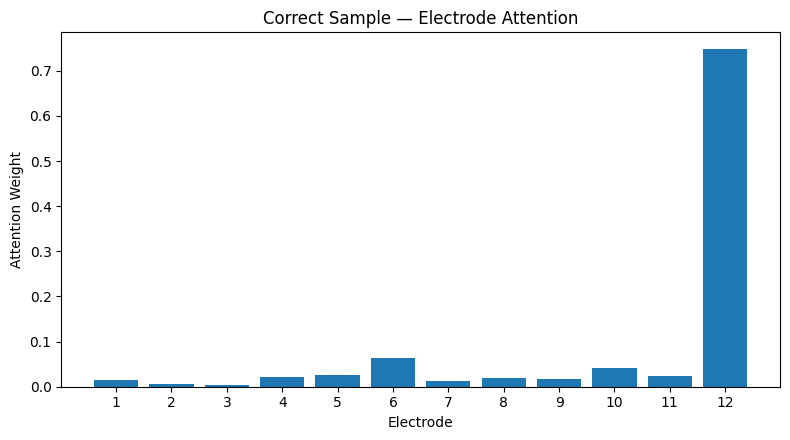

,Electrode Pair,Signed Correlation,Absolute Strength
3,Ch1-Ch7,+0.324,0.324
1,Ch1-Ch5,+0.218,0.218
28,Ch7-Ch8,+0.216,0.216
2,Ch1-Ch6,-0.204,0.204
24,Ch5-Ch12,-0.203,0.203
20,Ch5-Ch7,+0.189,0.189
27,Ch6-Ch10,-0.185,0.185
23,Ch5-Ch11,+0.181,0.181
4,Ch1-Ch11,+0.176,0.176
19,Ch5-Ch6,-0.172,0.172


,Electrode,Attention
0,Ch1,0.6474
7,Ch8,0.1665
10,Ch11,0.1474
1,Ch2,0.0126
4,Ch5,0.0081
11,Ch12,0.0050
9,Ch10,0.0030
5,Ch6,0.0027
2,Ch3,0.0027
6,Ch7,0.0020


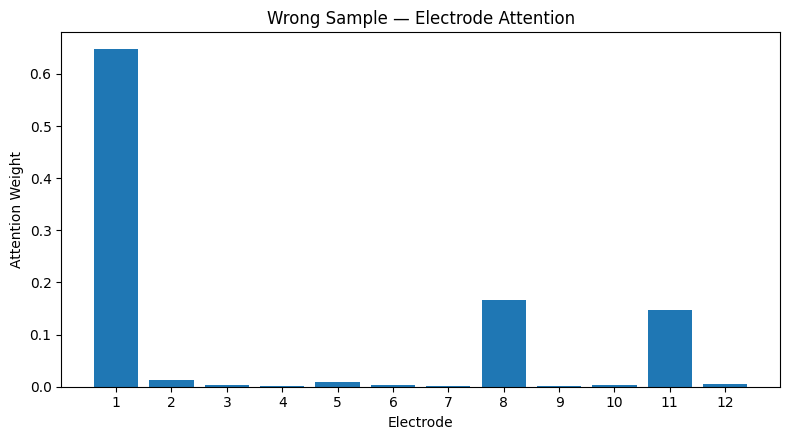

,Electrode Pair,Signed Correlation,Absolute Strength
27,Ch7-Ch8,+0.392,0.392
12,Ch3-Ch4,+0.366,0.366
16,Ch4-Ch5,+0.345,0.345
5,Ch2-Ch3,+0.316,0.316
17,Ch4-Ch6,+0.312,0.312
4,Ch1-Ch9,+0.273,0.273
30,Ch8-Ch10,-0.272,0.272
35,Ch11-Ch12,+0.237,0.237
11,Ch2-Ch12,+0.235,0.235
18,Ch4-Ch9,+0.222,0.222


In [12]:
full_test_correlations = build_full_correlation_matrices(
    final_test[
        "frame"
    ]
)


def graph_edge_table(
    index,
    top_n=10,
):
    correlation_matrix = full_test_correlations[
        index
    ]

    rows = []

    for i in range(
        N_CHANNELS
    ):
        for j in range(
            i + 1,
            N_CHANNELS
        ):
            if final_test_mask[
                index,
                i,
                j,
            ]:
                rows.append(
                    {
                        "Electrode Pair": f"Ch{i + 1}-Ch{j + 1}",
                        "Signed Correlation": float(
                            correlation_matrix[
                                i,
                                j,
                            ]
                        ),
                        "Absolute Strength": float(
                            abs(
                                correlation_matrix[
                                    i,
                                    j,
                                ]
                            )
                        ),
                    }
                )

    return pd.DataFrame(
        rows
    ).sort_values(
        "Absolute Strength",
        ascending=False,
    ).head(
        top_n
    )


print(
    "Graph mode:",
    final_config[
        "graph_mode"
    ],
)


for sample_type, index in [
    (
        "Correct",
        correct_index,
    ),
    (
        "Wrong",
        wrong_index,
    ),
]:
    attention = final_attention[
        index
    ]

    attention_df = pd.DataFrame(
        {
            "Electrode": [
                f"Ch{i}"
                for i
                in range(
                    1,
                    N_CHANNELS + 1,
                )
            ],
            "Attention": attention,
        }
    ).sort_values(
        "Attention",
        ascending=False,
    )

    display(
        attention_df.style.format(
            {
                "Attention": "{:.4f}",
            }
        )
    )

    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )

    ax.bar(
        np.arange(
            1,
            N_CHANNELS + 1,
        ),
        attention,
    )

    ax.set_title(
        f"{sample_type} Sample — Electrode Attention"
    )

    ax.set_xlabel(
        "Electrode"
    )

    ax.set_ylabel(
        "Attention Weight"
    )

    ax.set_xticks(
        np.arange(
            1,
            N_CHANNELS + 1,
        )
    )

    plt.tight_layout()
    plt.show()

    display(
        graph_edge_table(
            index,
            top_n=10,
        ).style.format(
            {
                "Signed Correlation": "{:+.3f}",
                "Absolute Strength": "{:.3f}",
            }
        )
    )


## 10. SHAP and LIME Setup

In [13]:
try:
    import shap
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "shap",
            "-q",
        ]
    )
    import shap

LIME_AVAILABLE = True

try:
    from lime.lime_tabular import LimeTabularExplainer
except ImportError:
    try:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "lime",
                "-q",
            ]
        )

        from lime.lime_tabular import LimeTabularExplainer
    except Exception:
        LIME_AVAILABLE = False


selected_scores = final_prep[
    "selector_scores"
][
    final_prep[
        "selector"
    ].get_support()
]

selected_names = np.asarray(
    final_prep[
        "selected_feature_names"
    ]
)

top_feature_indices = np.argsort(
    selected_scores
)[
    -20:
][
    ::-1
]

top_feature_names = selected_names[
    top_feature_indices
].tolist()

rng = np.random.default_rng(
    RANDOM_STATE
)

background_indices = rng.choice(
    len(
        final_train[
            "global"
        ]
    ),
    size=min(
        2000,
        len(
            final_train[
                "global"
            ]
        ),
    ),
    replace=False,
)

lime_training_data = final_train[
    "global"
][
    background_indices
][
    :,
    top_feature_indices
]

shap_background_indices = rng.choice(
    len(
        lime_training_data
    ),
    size=min(
        40,
        len(
            lime_training_data
        ),
    ),
    replace=False,
)

shap_background = lime_training_data[
    shap_background_indices
]

print("SHAP version       :", shap.__version__)
print("LIME available     :", LIME_AVAILABLE)
print("Explained features :", len(top_feature_names))
print("Background rows    :", len(shap_background))

display(
    pd.DataFrame(
        {
            "Rank": np.arange(
                1,
                len(
                    top_feature_names
                )
                + 1,
            ),
            "Feature": top_feature_names,
            "Training ANOVA Score": selected_scores[
                top_feature_indices
            ],
        }
    ).head(
        20
    )
)


SHAP version       : 0.51.0
LIME available     : True
Explained features : 20
Background rows    : 40


,Rank,Feature,Training ANOVA Score
0,1,ch11_WAMP,2092.912295
1,2,ch11_RMS,1673.474883
2,3,ch11_DASDV,1606.961440
3,4,ch11_IEMG,1606.888649
4,5,ch11_MAV,1606.884253
5,6,ch11_WL,1572.981731
6,7,ch04_WAMP,1485.443662
7,8,ch11_LOGDET,1479.096415
8,9,ch04_WL,1128.011273
9,10,ch04_DASDV,1094.363636


## 11. Local Prediction Wrapper

In [14]:
def local_predictor(
    sample_index,
):
    fixed_raw = final_test[
        "raw"
    ][
        sample_index
    ].T

    fixed_raw = (
        (
            fixed_raw
            - final_prep[
                "raw_mean"
            ].reshape(
                N_CHANNELS,
                1,
            )
        )
        / final_prep[
            "raw_std"
        ].reshape(
            N_CHANNELS,
            1,
        )
    ).astype(
        np.float32
    )

    fixed_nodes = final_test[
        "nodes"
    ][
        sample_index
    ].astype(
        np.float32
    )

    fixed_edges = final_test_edges[
        sample_index
    ].astype(
        np.float32
    )

    fixed_mask = final_test_mask[
        sample_index
    ]

    base_global = final_test[
        "global"
    ][
        sample_index
    ].copy()

    def predict(
        reduced_features,
    ):
        reduced_features = np.asarray(
            reduced_features,
            dtype=np.float32,
        )

        if reduced_features.ndim == 1:
            reduced_features = reduced_features.reshape(
                1,
                -1,
            )

        n_rows = len(
            reduced_features
        )

        full_global = np.repeat(
            base_global.reshape(
                1,
                -1,
            ),
            n_rows,
            axis=0,
        )

        full_global[
            :,
            top_feature_indices
        ] = reduced_features

        probabilities = []

        batch_size = 256

        for start in range(
            0,
            n_rows,
            batch_size,
        ):
            end = min(
                start
                + batch_size,
                n_rows,
            )

            current = (
                end
                - start
            )

            raw_batch = torch.from_numpy(
                np.repeat(
                    fixed_raw[
                        None,
                        :,
                        :,
                    ],
                    current,
                    axis=0,
                )
            ).to(
                DEVICE
            )

            node_batch = torch.from_numpy(
                np.repeat(
                    fixed_nodes[
                        None,
                        :,
                        :,
                    ],
                    current,
                    axis=0,
                )
            ).to(
                DEVICE
            )

            edge_batch = torch.from_numpy(
                np.repeat(
                    fixed_edges[
                        None,
                        :,
                        :,
                    ],
                    current,
                    axis=0,
                )
            ).to(
                DEVICE
            )

            mask_batch = torch.from_numpy(
                np.repeat(
                    fixed_mask[
                        None,
                        :,
                        :,
                    ],
                    current,
                    axis=0,
                )
            ).to(
                DEVICE
            )

            global_batch = torch.from_numpy(
                full_global[
                    start:end
                ].astype(
                    np.float32
                )
            ).to(
                DEVICE
            )

            with torch.no_grad():
                logits = final_model(
                    raw_batch,
                    node_batch,
                    edge_batch,
                    mask_batch,
                    global_batch,
                )

                proba = torch.softmax(
                    logits.float(),
                    dim=1,
                ).cpu().numpy()

            probabilities.append(
                proba
            )

        return np.vstack(
            probabilities
        )

    return predict


print("Local model wrapper: READY")


Local model wrapper: READY


## 12. SHAP — Correct and Wrong Samples

,Feature,SHAP Value,Absolute SHAP
0,ch11_WAMP,+0.00090,0.00090
1,ch11_RMS,+0.00090,0.00090
2,ch02_IEMG,+0.00080,0.00080
3,ch11_WL,+0.00073,0.00073
4,ch11_SSC,+0.00062,0.00062
5,ch02_LOGDET,+0.00049,0.00049
6,ch11_LOGDET,+0.00039,0.00039
7,ch11_DASDV,+0.00025,0.00025
8,ch11_IEMG,+0.00017,0.00017
9,ch04_LOGDET,+0.00015,0.00015


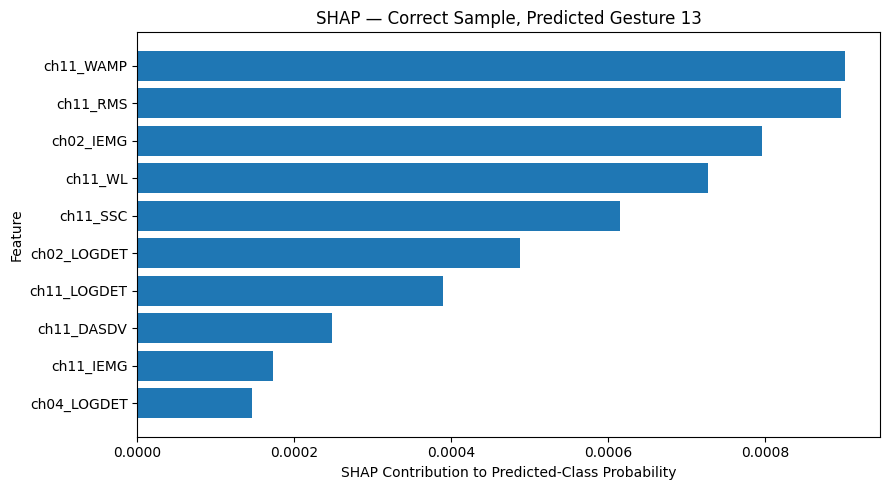

,Feature,SHAP Value,Absolute SHAP
0,ch11_WAMP,+0.04519,0.04519
1,ch04_WAMP,+0.02657,0.02657
2,ch02_MAV,+0.02247,0.02247
3,ch11_WL,+0.01848,0.01848
4,ch11_DASDV,+0.01576,0.01576
5,ch02_IEMG,+0.01531,0.01531
6,ch04_DASDV,+0.01346,0.01346
7,ch04_LOGDET,+0.01097,0.01097
8,ch04_RMS,+0.01079,0.01079
9,ch11_RMS,+0.00858,0.00858


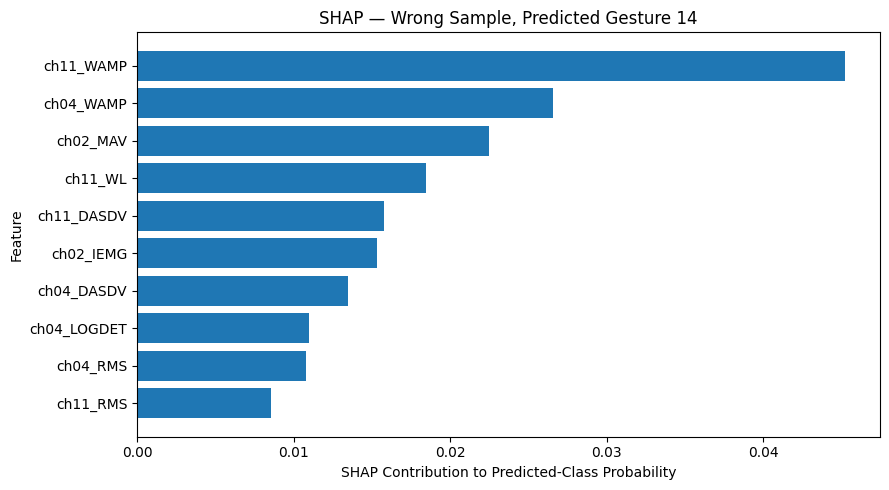

In [15]:
shap_results = {}

for sample_type, index in [
    (
        "Correct",
        correct_index,
    ),
    (
        "Wrong",
        wrong_index,
    ),
]:
    predictor = local_predictor(
        index
    )

    sample_features = final_test[
        "global"
    ][
        index,
        top_feature_indices
    ].reshape(
        1,
        -1,
    )

    predicted_class = int(
        final_pred[
            index
        ]
    )

    explainer = shap.KernelExplainer(
        predictor,
        shap_background,
    )

    shap_values = explainer.shap_values(
        sample_features,
        nsamples=120,
        silent=True,
    )

    if isinstance(
        shap_values,
        list,
    ):
        class_values = np.asarray(
            shap_values[
                predicted_class
            ]
        ).reshape(
            -1
        )
    else:
        shap_array = np.asarray(
            shap_values
        )

        if shap_array.ndim == 3:
            class_values = shap_array[
                0,
                :,
                predicted_class,
            ]
        elif shap_array.ndim == 2:
            class_values = shap_array[
                0
            ]
        else:
            class_values = shap_array.reshape(
                -1
            )

    shap_df = pd.DataFrame(
        {
            "Feature": top_feature_names,
            "SHAP Value": class_values,
            "Absolute SHAP": np.abs(
                class_values
            ),
        }
    ).sort_values(
        "Absolute SHAP",
        ascending=False,
    ).reset_index(
        drop=True
    )

    shap_results[
        sample_type
    ] = shap_df

    display(
        shap_df.head(
            10
        ).style.format(
            {
                "SHAP Value": "{:+.5f}",
                "Absolute SHAP": "{:.5f}",
            }
        )
    )

    plot_df = shap_df.head(
        10
    ).sort_values(
        "SHAP Value"
    )

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    ax.barh(
        plot_df[
            "Feature"
        ],
        plot_df[
            "SHAP Value"
        ],
    )

    ax.set_title(
        f"SHAP — {sample_type} Sample, Predicted Gesture {predicted_class + 1}"
    )

    ax.set_xlabel(
        "SHAP Contribution to Predicted-Class Probability"
    )

    ax.set_ylabel(
        "Feature"
    )

    plt.tight_layout()
    plt.show()

## 13. LIME — Correct and Wrong Samples

,Feature Condition,LIME Weight,Absolute Weight
0,ch11_WAMP <= -0.36,+0.00224,0.00224
1,ch09_WAMP <= -0.74,+0.00106,0.00106
2,ch02_LOGDET <= -0.54,+0.00105,0.00105
3,-0.42 < ch04_WL <= -0.32,+0.00096,0.00096
4,ch02_IEMG <= -0.55,+0.00093,0.00093
5,-0.36 < ch11_RMS <= -0.32,+0.00082,0.00082
6,-0.43 < ch04_DASDV <= -0.33,-0.00064,0.00064
7,-0.30 < ch11_DASDV <= -0.11,+0.00052,0.00052
8,-0.28 < ch11_WL <= -0.12,+0.00052,0.00052
9,ch11_ZC > 0.73,-0.00033,0.00033


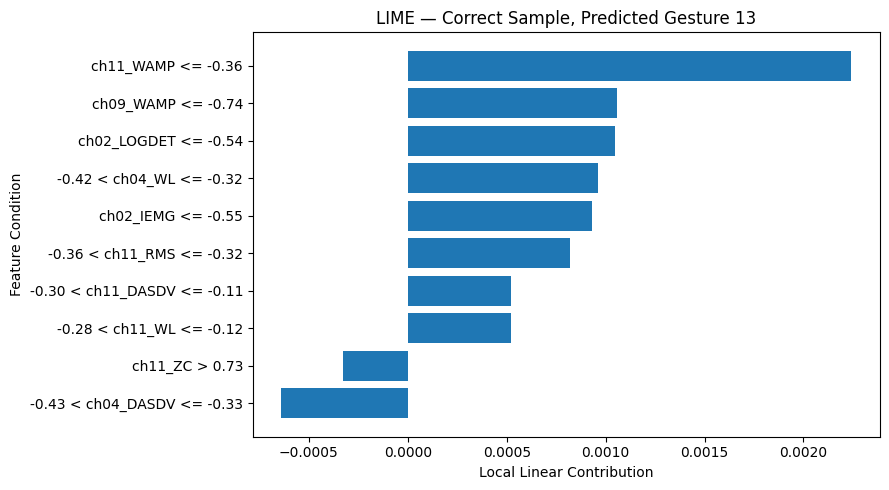

,Feature Condition,LIME Weight,Absolute Weight
0,ch11_RMS > -0.07,+0.11665,0.11665
1,ch11_WAMP > -0.24,-0.09697,0.09697
2,ch11_SSC <= -0.57,+0.09670,0.09670
3,ch02_IEMG <= -0.55,+0.08606,0.08606
4,ch04_IEMG <= -0.45,+0.06965,0.06965
5,ch02_MAV <= -0.55,+0.05806,0.05806
6,-0.74 < ch09_WAMP <= -0.58,+0.05311,0.05311
7,ch04_DASDV <= -0.43,+0.05105,0.05105
8,ch04_LOGDET <= -0.45,+0.04922,0.04922
9,ch02_LOGDET <= -0.54,+0.04888,0.04888


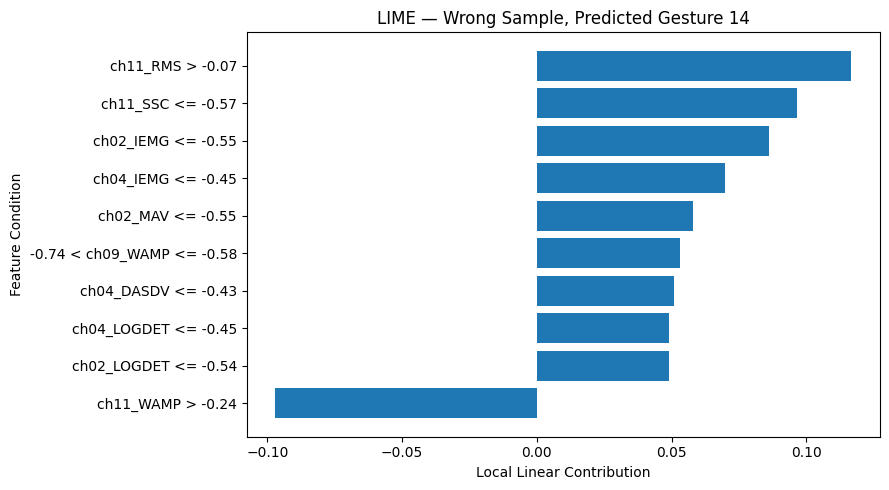

In [16]:
lime_results = {}

if LIME_AVAILABLE:
    lime_explainer = LimeTabularExplainer(
        lime_training_data,
        feature_names=top_feature_names,
        class_names=[
            f"Gesture {gesture}"
            for gesture
            in range(
                1,
                N_CLASSES + 1,
            )
        ],
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )

    for sample_type, index in [
        (
            "Correct",
            correct_index,
        ),
        (
            "Wrong",
            wrong_index,
        ),
    ]:
        predictor = local_predictor(
            index
        )

        sample_features = final_test[
            "global"
        ][
            index,
            top_feature_indices
        ]

        predicted_class = int(
            final_pred[
                index
            ]
        )

        explanation = lime_explainer.explain_instance(
            sample_features,
            predictor,
            labels=[
                predicted_class
            ],
            num_features=10,
            num_samples=1500,
        )

        pairs = explanation.as_list(
            label=predicted_class
        )

        lime_df = pd.DataFrame(
            pairs,
            columns=[
                "Feature Condition",
                "LIME Weight",
            ],
        )

        lime_df[
            "Absolute Weight"
        ] = np.abs(
            lime_df[
                "LIME Weight"
            ]
        )

        lime_df = lime_df.sort_values(
            "Absolute Weight",
            ascending=False,
        ).reset_index(
            drop=True
        )

        lime_results[
            sample_type
        ] = lime_df

        display(
            lime_df.style.format(
                {
                    "LIME Weight": "{:+.5f}",
                    "Absolute Weight": "{:.5f}",
                }
            )
        )

        plot_df = lime_df.sort_values(
            "LIME Weight"
        )

        fig, ax = plt.subplots(
            figsize=(9, 5)
        )

        ax.barh(
            plot_df[
                "Feature Condition"
            ],
            plot_df[
                "LIME Weight"
            ],
        )

        ax.set_title(
            f"LIME — {sample_type} Sample, Predicted Gesture {predicted_class + 1}"
        )

        ax.set_xlabel(
            "Local Linear Contribution"
        )

        ax.set_ylabel(
            "Feature Condition"
        )

        plt.tight_layout()
        plt.show()
else:
    print(
        "LIME could not be imported. Enable Kaggle internet once, run `pip install lime`, and rerun this section."
    )

## 14. Correct vs Wrong Explanation Summary

In [17]:
summary_rows = []

for sample_type, index in [
    (
        "Correct",
        correct_index,
    ),
    (
        "Wrong",
        wrong_index,
    ),
]:
    top_shap = shap_results[
        sample_type
    ].iloc[
        0
    ]

    top_electrode = int(
        np.argmax(
            final_attention[
                index
            ]
        )
        + 1
    )

    row = {
        "Sample": sample_type,
        "Subject": int(
            final_test[
                "frame"
            ].iloc[
                index
            ][
                "subject_id"
            ]
        ),
        "Actual Gesture": int(
            final_true[
                index
            ]
            + 1
        ),
        "Predicted Gesture": int(
            final_pred[
                index
            ]
            + 1
        ),
        "Confidence": float(
            final_proba[
                index,
                final_pred[
                    index
                ],
            ]
        ),
        "Top SHAP Feature": top_shap[
            "Feature"
        ],
        "Top Electrode": f"Ch{top_electrode}",
    }

    if (
        LIME_AVAILABLE
        and sample_type
        in lime_results
    ):
        row[
            "Top LIME Condition"
        ] = lime_results[
            sample_type
        ].iloc[
            0
        ][
            "Feature Condition"
        ]
    else:
        row[
            "Top LIME Condition"
        ] = "Unavailable"

    summary_rows.append(
        row
    )

explanation_summary_df = pd.DataFrame(
    summary_rows
)

display(
    explanation_summary_df.style.format(
        {
            "Confidence": "{:.2%}",
        }
    )
)

,Sample,Subject,Actual Gesture,Predicted Gesture,Confidence,Top SHAP Feature,Top Electrode,Top LIME Condition
0,Correct,31,13,13,99.92%,ch11_WAMP,Ch12,ch11_WAMP <= -0.36
1,Wrong,26,13,14,99.69%,ch11_WAMP,Ch1,ch11_RMS > -0.07
